# 07221203_2025 — dump 1 noise-pulse survey

Series `07221203_2025`, dump `F0001` (Run76: Side2, PuBe/Pb&poly lead-stack/borax,
-83.2 V). Picking out clean noise traces on **Detector 0, Channel 0 only** as a starting
point for a PSD study. Run with the `darkmatter_cli_env` conda environment.

Uses the shared `python/` library (`pulse_io`/`pulse_quantities`/`pulse_cuts`) instead
of ad-hoc per-trace loops — see `python/README.md` for the conventions.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parents[1] / "python"))

from nsdf_dark_matter.idx import load_all_data

import numpy as np
import matplotlib.pyplot as plt

import pulse_io as pio
import pulse_quantities as pq
import pulse_cuts as pc
from pulse_config import PulseConfig

home_directory = Path.home()
series_path = str(home_directory) + '/idx/07221203_2025_F0001'
cdms = load_all_data(series_path)

detector_ids = cdms.get_detector_ids()
print(f"channel groups (detector_ids): {len(detector_ids)}")

channel groups (detector_ids): 4551


### Note: leading-sample glitch

A number of traces have a brief electronic glitch (a step offset) in the first few
samples, before the real baseline settles — sampled 25 random traces and found leading
runs of 1-5 anomalous samples in several of them (relative to a robust estimate from
samples 200-1000), separate from the handful of traces with a genuine pulse/drift
extending much further in. `config.glitch_samples = 10` below skips that leading run
when computing the pretrigger `bmean`/`bstd` (via `pulse_quantities`), with margin. It
does **not** fix traces where the contamination is a real pulse spanning hundreds of
samples — that's a different, legitimate problem the cut still has to handle.

In [2]:
DETECTOR = 0
CHANNEL = 0
config = PulseConfig(pretrigger_samples=1000, glitch_samples=10, sample_period_s=1.6e-6)
PRETRIGGER_SAMPLES = config.pretrigger_samples  # kept for readability in later cells

detector0_ids = pio.filter_by_detector(detector_ids, DETECTOR)
detector_id_arr, pulses = pio.load_channel_batch(cdms, detector0_ids, CHANNEL)

bmean_arr = pq.pretrigger_mean(pulses, config)
bstd_arr = pq.pretrigger_std(pulses, config)
dev_arr = pq.max_deviation(pulses, config)
ratio_arr = pq.excursion_ratio(pulses, config)

print(f"detector {DETECTOR}, channel {CHANNEL} traces: {len(detector_id_arr)}")

detector 0, channel 0 traces: 1517


## Good noise selection

Cut, relative to Detector 0/Channel 0's own distribution: `bstd` below its 75th
percentile (quiet baseline) and `ratio = dev/bstd` below its 25th percentile (no
post-baseline excursion). `dev` is measured in the post-pretrigger region only (samples
1000-4096) — measuring it over the whole trace instead puts an artificial floor around
`ratio ~ 1` regardless of threshold.

In [3]:
BSTD_CAP_PERCENTILE = 75
RATIO_THRESH_PERCENTILE = 25

good_mask = (
    pc.quiet_baseline(pulses, config, percentile=BSTD_CAP_PERCENTILE, bstd=bstd_arr)
    & pc.excursion_below_percentile(pulses, config, percentile=RATIO_THRESH_PERCENTILE, ratio=ratio_arr)
)

bstd_cap = np.percentile(bstd_arr[bstd_arr > 0], BSTD_CAP_PERCENTILE)
ratio_thresh = np.percentile(ratio_arr[np.isfinite(ratio_arr)], RATIO_THRESH_PERCENTILE)
print(f"bstd_cap={bstd_cap:.2f}, ratio_thresh={ratio_thresh:.2f}")
print(f"good noise traces: {good_mask.sum()} / {len(detector_id_arr)}")

good_detector_ids = detector_id_arr[good_mask]

bstd_cap=32.48, ratio_thresh=1.93
good noise traces: 41 / 1517


/var/folders/qs/y0dxxqrn4rd_pc96p6hnq51w0000gn/T/ipykernel_5973/1942965242.py:6: UserWarning: excursion_below_percentile is marked under_development: matches the original dump1_noise 'good noise' cut, which the same notebook's widened-Cut-A investigation found is biased toward contaminated-baseline traces rather than quiet ones when used alone -- combine with quiet_baseline (already the notebook's practice) rather than relying on this in isolation
  & pc.excursion_below_percentile(pulses, config, percentile=RATIO_THRESH_PERCENTILE, ratio=ratio_arr)


In [4]:
from IPython.display import display, HTML
import csv

rows = []
for i in np.where(good_mask)[0]:
    detector_id = detector_id_arr[i]
    event_id, *_ = detector_id.split('_')
    rows.append({
        "event": event_id,
        "bstd": round(float(bstd_arr[i]), 3),
        "dev": round(float(dev_arr[i]), 3),
        "ratio": round(float(ratio_arr[i]), 3),
    })
rows.sort(key=lambda r: int(r["event"]))

csv_path = "good_noise_det0_ch0.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)
print(f"saved {len(rows)} rows to {csv_path} (previewing first 10 below)\n")

html = ["<table><tr>" + "".join(f"<th>{k}</th>" for k in rows[0].keys()) + "</tr>"]
for r in rows[:10]:
    html.append("<tr>" + "".join(f"<td>{v}</td>" for v in r.values()) + "</tr>")
html.append("</table>")
display(HTML("".join(html)))

saved 41 rows to good_noise_det0_ch0.csv (previewing first 10 below)



event,bstd,dev,ratio
10085,16.583,29.917,1.804
10347,29.67,41.076,1.384
10431,11.149,16.396,1.471
10508,8.755,14.722,1.682
10529,13.768,21.672,1.574
10858,27.355,45.022,1.646
11083,16.459,19.988,1.214
11114,20.081,34.366,1.711
11141,17.963,25.804,1.436
11142,24.04,31.096,1.293


## Ratio histogram, `dev > 0` only

Same idea as the ratio histogram in `dump1_noise_pulses.ipynb`, but pre-removing any
trace with `dev == 0` first: `log10(ratio)` is `-inf` for those (there happen to be none
for Detector 0/Channel 0 in this dump, but the filter guards against it regardless).

Overlaid (transparent) is the same computation with the pretrigger window shortened to
500 samples instead of 1000 (still skipping the leading glitch samples) — not carried
through the cut, just compared here to see whether the two peaks are an artifact of the
1000-sample window choice.

detector 0, channel 0 traces with dev == 0 (excluded): 0


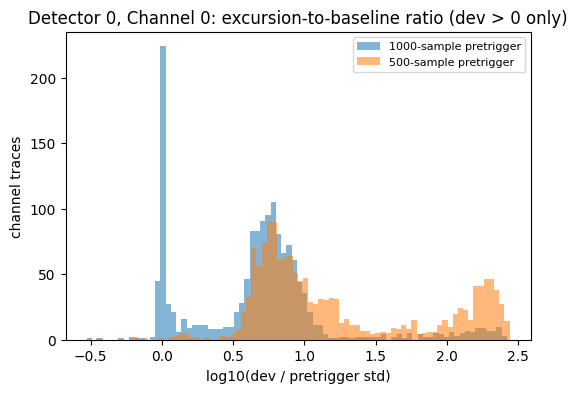

In [5]:
nonzero_dev = dev_arr > 0
print(f"detector {DETECTOR}, channel {CHANNEL} traces with dev == 0 (excluded): {(~nonzero_dev).sum()}")

# same analysis with a shorter (500-sample) pretrigger window, for comparison only --
# not carried through the rest of the notebook
config_500 = PulseConfig(pretrigger_samples=500, glitch_samples=config.glitch_samples,
                          sample_period_s=config.sample_period_s)
bstd_arr_500 = pq.pretrigger_std(pulses, config_500)
dev_arr_500 = pq.max_deviation(pulses, config_500)
ratio_arr_500 = dev_arr_500 / bstd_arr_500
nonzero_dev_500 = dev_arr_500 > 0

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.log10(ratio_arr[nonzero_dev]), bins=80, alpha=0.55, label="1000-sample pretrigger")
ax.hist(np.log10(ratio_arr_500[nonzero_dev_500]), bins=80, alpha=0.55, label="500-sample pretrigger")
ax.set_xlabel("log10(dev / pretrigger std)")
ax.set_ylabel("channel traces")
ax.set_title(f"Detector {DETECTOR}, Channel {CHANNEL}: excursion-to-baseline ratio (dev > 0 only)")
ax.legend(fontsize=8)
plt.show()

## Branching point

The histogram above shows the "good noise" cut's near-`log10(ratio) = 0` selection
(used above, on the 1000-sample window) sitting right next to a spike that mostly
turns out to be pulse-contaminated baselines, while the 500-sample window's
broad hump (~0.5-1.4) stays clean and in the same place regardless of window length.
Two ways to go from here:

- **Branch 1** keeps working with the 1000-sample near-zero selection and tests
  *why* it clusters the way it does (a hypothesis, not yet verified).
- **Branch 2** instead cuts directly on the 500-sample window's clean hump as a
  candidate selection in its own right.

## Branch 1: the 1000-sample near-`log10(ratio) = 0` cut

Same idea as "Good noise selection" above, just widened (to `log10(ratio)` in
`[-0.05, 0.48)`) for enough statistics to test a hypothesis about *why* traces land
there. A few example traces, baseline-subtracted and overlaid.

In [6]:
log_ratio_arr = np.log10(ratio_arr)

cut_a_mask = nonzero_dev & (log_ratio_arr >= -0.05) & (log_ratio_arr < 0.48)
cut_a_indices = np.where(cut_a_mask)[0]

print(f"cut A (widened, near zero to 0.48): {cut_a_mask.sum()} traces")

rng = np.random.default_rng(0)
n_show = 8
cut_a_show = rng.choice(cut_a_indices, size=n_show, replace=False)

cut A (widened, near zero to 0.48): 417 traces


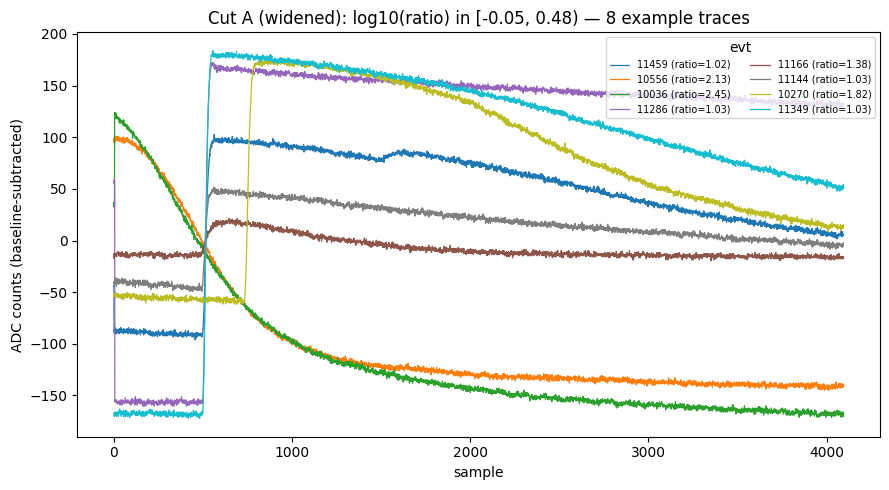

In [7]:
colors_a = plt.cm.tab10(np.linspace(0, 1, n_show))

fig, ax = plt.subplots(figsize=(9, 5))
for i, color in zip(cut_a_show, colors_a):
    trace = pulses[i] - bmean_arr[i]
    ax.plot(trace, linewidth=0.9, color=color,
             label=f"{detector_id_arr[i].split('_')[0]} (ratio={ratio_arr[i]:.2f})")
ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted)")
ax.set_title(f"Cut A (widened): log10(ratio) in [-0.05, 0.48) — {n_show} example traces")
ax.legend(fontsize=7, ncol=2, loc="upper right", title="evt")
fig.tight_layout()
plt.show()

### Cut B, for comparison: the 1000-sample broad hump

Same 1000-sample window as Cut A, but the broad hump instead of the near-zero spike:
`log10(ratio)` in `[0.5, 1.0)`. Kept here as a direct comparison against Cut A above
and Branch 2 below -- same plotting style as Branch 2 (up to 30 example traces, total
retained annotated on the plot).

cut B (0.5 to 1.0): 892 / 1517 traces retained


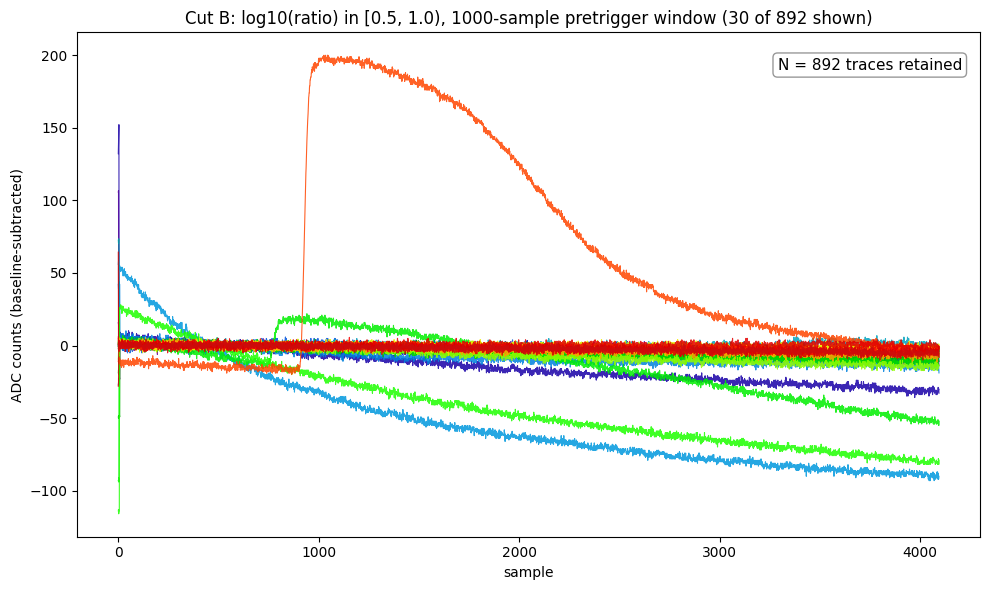

In [8]:
cut_b_mask = nonzero_dev & (log_ratio_arr >= 0.5) & (log_ratio_arr < 1.0)
cut_b_indices = np.where(cut_b_mask)[0]

print(f"cut B (0.5 to 1.0): {cut_b_mask.sum()} / {len(detector_id_arr)} traces retained")

N_SHOW_CUT_B = min(30, len(cut_b_indices))  # as many as stay visually distinguishable
rng_b = np.random.default_rng(0)
cut_b_show = rng_b.choice(cut_b_indices, size=N_SHOW_CUT_B, replace=False)
colors_cut_b = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, N_SHOW_CUT_B))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(cut_b_show, colors_cut_b):
    trace = pulses[i] - bmean_arr[i]
    ax.plot(trace, linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted)")
ax.set_title(f"Cut B: log10(ratio) in [0.5, 1.0), 1000-sample pretrigger window "
             f"({N_SHOW_CUT_B} of {cut_b_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {cut_b_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

<div style="border: 2px solid #cc0000; background-color: #fff0f0; padding: 12px; border-radius: 6px; margin-bottom: 12px;">
<span style="color: #cc0000; font-weight: bold; font-size: 1.05em;">UNVERIFIED</span><br>
This section (through the "Confirmed" cell below) rests on <code>pulse_quantities.rise_sample</code>,
which is tagged <code>under_development</code> in <code>python/pulse_quantities.py</code> — a
half-max-crossing heuristic validated on exactly this one analysis, not yet checked against
noisy or multi-peak traces. Treat the correlation and conclusion below as a working
hypothesis, not a settled result, until that function has been independently checked.
Collapsed by default in JupyterLab (click to expand) — same caveat applies wherever that
collapse doesn't render.
</div>

### Unverified: does rise time track `ratio` across all of Cut A?

The suspicion: if these pulses have similar amplitude, then how much of the 1000-sample
pretrigger window a pulse contaminates determines `bstd` (more contamination -> larger
`bstd`), and `ratio = dev/bstd` for a fixed `dev` is then *smaller* the more of the
window got contaminated — i.e. smaller `ratio` should mean an *earlier* rise (more of
the pretrigger swallowed by the pulse), not a random sample of rise times. Estimate a
per-trace "rise sample" (first post-pretrigger sample where the trace crosses half of
its own `dev`) for every trace in the widened Cut A, not just the 8 shown above, and
plot rise sample vs. `ratio`.

/var/folders/qs/y0dxxqrn4rd_pc96p6hnq51w0000gn/T/ipykernel_5973/1107070782.py:1: UserWarning: rise_sample is marked under_development: fraction=0.5 half-max crossing heuristic; only validated on one exploratory analysis (07221203_2025_dump1_noise.ipynb's Cut A rise-time check) -- not yet checked against noisy/multi-peak traces
  rise_samples = pq.rise_sample(pulses[cut_a_indices], config)


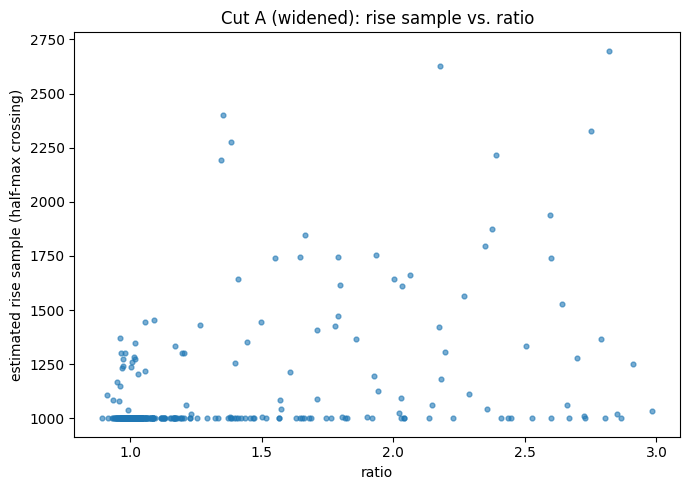

Pearson correlation (ratio, rise sample): 0.452
rise sample range: 1000 to 2698


In [9]:
rise_samples = pq.rise_sample(pulses[cut_a_indices], config)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ratio_arr[cut_a_indices], rise_samples, s=12, alpha=0.6)
ax.set_xlabel("ratio")
ax.set_ylabel("estimated rise sample (half-max crossing)")
ax.set_title("Cut A (widened): rise sample vs. ratio")
fig.tight_layout()
plt.show()

corr = np.corrcoef(ratio_arr[cut_a_indices], rise_samples)[0, 1]
print(f"Pearson correlation (ratio, rise sample): {corr:.3f}")
print(f"rise sample range: {rise_samples.min()} to {rise_samples.max()}")

**Confirmed — the original narrow slice was hiding the spread, not revealing a real
clustering.** Correlation of 0.45 between `ratio` and rise sample, and rise samples
now span 1000 to 2698 (vs. everything piling up around sample 500-600 in the original
narrow `[-0.05, 0.05)` slice). The scatter has two components:

- A large group sitting exactly at `rise_sample = 1000` across a wide range of `ratio`
  (roughly 0.9 to 2.5). This is a floor artifact of the detection method, not a real
  clustering: these pulses already crossed half-max *before* sample 1000, inside the
  pretrigger window itself, so "first post-pretrigger crossing" reports the boundary
  rather than the true onset. These are exactly the fully-pretrigger-contaminated cases
  the earlier note described.
- A clear rising trend above that floor: traces with `ratio` from ~1.3 up to ~2.9 have
  rise samples spreading smoothly from ~1200 out to ~2700. For pulses of similar
  amplitude, less of the pretrigger window gets contaminated the later the pulse
  actually rises — smaller contamination means smaller `bstd`, which (for similar `dev`)
  means *larger* `ratio`. That's exactly the mechanism proposed, and it's what's in the
  data once the cut isn't narrow enough to hide it.

## Branch 2: cut on the 500-sample window, `log10(ratio)` in `[0.5, 1.4)`

Why not just keep refining Branch 1: `dev` is the *max* of ~3000 post-baseline samples,
so even pure Gaussian noise is expected to land around `ratio ~ 3-8` by extreme-value
statistics — a trace only reaches `ratio ~ 1` (Branch 1's selection) if its pretrigger
window is itself already contaminated (part of a pulse or a slow transition inflating
`bstd`), not because it's unusually quiet. The 500-sample histogram overlay above
showed exactly this: the near-zero spike vanishes at 500 samples, while the broad hump
stays in place regardless of window length — that hump is the genuinely quiet
population.

This branch cuts directly on that hump instead: `log10(ratio_arr_500)` in
`[0.5, 1.4)`, `dev_500 > 0`. As many example traces as stay visually distinguishable
are overlaid below, with the *total* number retained by the cut annotated on the plot
(not just the number shown).

In [10]:
bmean_arr_500 = pq.pretrigger_mean(pulses, config_500)

log_ratio_arr_500 = np.log10(ratio_arr_500)

branch2_mask = nonzero_dev_500 & (log_ratio_arr_500 >= 0.5) & (log_ratio_arr_500 < 1.4)
branch2_indices = np.where(branch2_mask)[0]

print(f"branch 2 (500-sample window, log10(ratio) in [0.5, 1.4)): "
      f"{branch2_mask.sum()} / {len(detector_id_arr)} traces retained")

branch 2 (500-sample window, log10(ratio) in [0.5, 1.4)): 1012 / 1517 traces retained


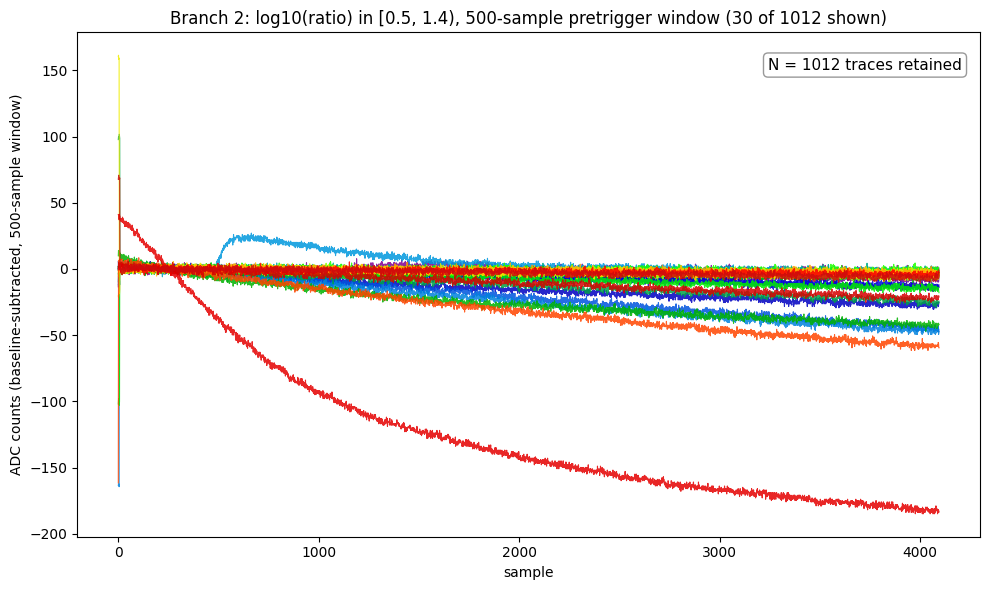

In [11]:
N_SHOW_BRANCH2 = min(30, len(branch2_indices))  # as many as stay visually distinguishable

rng2 = np.random.default_rng(0)
branch2_show = rng2.choice(branch2_indices, size=N_SHOW_BRANCH2, replace=False)
colors_branch2 = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, N_SHOW_BRANCH2))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(branch2_show, colors_branch2):
    trace = pulses[i] - bmean_arr_500[i]
    ax.plot(trace, linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"Branch 2: log10(ratio) in [0.5, 1.4), 500-sample pretrigger window "
             f"({N_SHOW_BRANCH2} of {branch2_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {branch2_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

### Branch 2, shoulder: `log10(ratio)` in `[1.0, 1.4)`

The upper shoulder of Branch 2's own range -- same 500-sample window, same cut family,
just the higher-`ratio` slice of it on its own, to see whether it still looks like the
same clean population or starts drifting toward something else.

branch 2 shoulder (1.0 to 1.4): 268 / 1517 traces retained


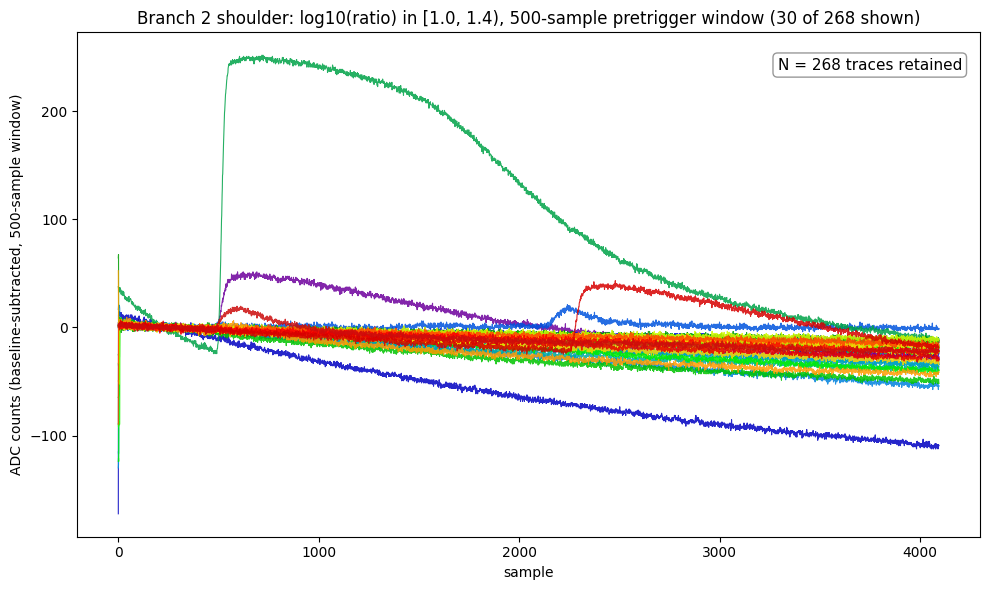

In [12]:
shoulder_mask = nonzero_dev_500 & (log_ratio_arr_500 >= 1.0) & (log_ratio_arr_500 < 1.4)
shoulder_indices = np.where(shoulder_mask)[0]

print(f"branch 2 shoulder (1.0 to 1.4): {shoulder_mask.sum()} / {len(detector_id_arr)} traces retained")

N_SHOW_SHOULDER = min(30, len(shoulder_indices))  # as many as stay visually distinguishable
rng_shoulder = np.random.default_rng(0)
shoulder_show = rng_shoulder.choice(shoulder_indices, size=N_SHOW_SHOULDER, replace=False)
colors_shoulder = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, N_SHOW_SHOULDER))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(shoulder_show, colors_shoulder):
    trace = pulses[i] - bmean_arr_500[i]
    ax.plot(trace, linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"Branch 2 shoulder: log10(ratio) in [1.0, 1.4), 500-sample pretrigger window "
             f"({N_SHOW_SHOULDER} of {shoulder_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {shoulder_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

### Branch 2, high tail: `log10(ratio) >= 2.0`

Well outside Branch 2's own `[0.5, 1.4)` selection -- events with a much larger
post-baseline excursion relative to the (500-sample) pretrigger scatter. Same window,
same `dev_500 > 0` filter, no upper bound.

branch 2 high tail (>= 2.0): 346 / 1517 traces retained


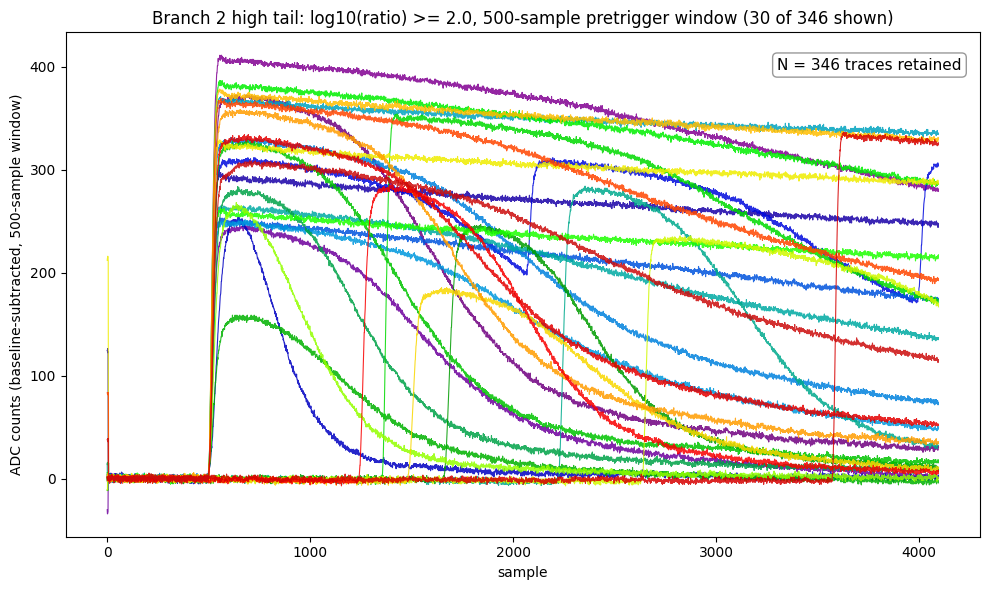

In [13]:
high_tail_mask = nonzero_dev_500 & (log_ratio_arr_500 >= 2.0)
high_tail_indices = np.where(high_tail_mask)[0]

print(f"branch 2 high tail (>= 2.0): {high_tail_mask.sum()} / {len(detector_id_arr)} traces retained")

N_SHOW_HIGH_TAIL = min(30, len(high_tail_indices))  # as many as stay visually distinguishable
rng_high_tail = np.random.default_rng(0)
high_tail_show = rng_high_tail.choice(high_tail_indices, size=N_SHOW_HIGH_TAIL, replace=False)
colors_high_tail = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, N_SHOW_HIGH_TAIL))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(high_tail_show, colors_high_tail):
    trace = pulses[i] - bmean_arr_500[i]
    ax.plot(trace, linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"Branch 2 high tail: log10(ratio) >= 2.0, 500-sample pretrigger window "
             f"({N_SHOW_HIGH_TAIL} of {high_tail_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {high_tail_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

## Loose cut: `log10(ratio)` in `[0.5, 1.0)`

The looser of the two narrowed cuts within Branch 2's range (500-sample window). It
stops short of the shoulder (`[1.0, 1.4)`, shown above to already have some
contamination creeping in) but still keeps 744 traces; the Tight cut below trades
statistics for a cleaner selection. This is the library's `excursion_band_loose`.

loose (0.5 to 1.0): 744 / 1517 traces retained


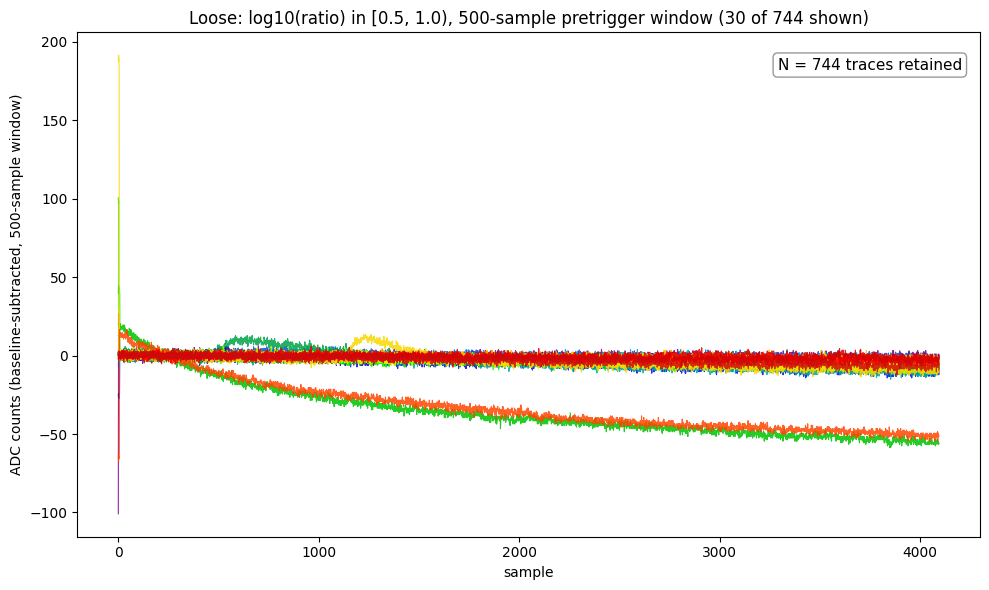

In [14]:
loose_mask = nonzero_dev_500 & (log_ratio_arr_500 >= 0.5) & (log_ratio_arr_500 < 1.0)
loose_indices = np.where(loose_mask)[0]

print(f"loose (0.5 to 1.0): {loose_mask.sum()} / {len(detector_id_arr)} traces retained")

N_SHOW_LOOSE = min(30, len(loose_indices))  # as many as stay visually distinguishable
rng_loose = np.random.default_rng(0)
loose_show = rng_loose.choice(loose_indices, size=N_SHOW_LOOSE, replace=False)
colors_loose = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, N_SHOW_LOOSE))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(loose_show, colors_loose):
    trace = pulses[i] - bmean_arr_500[i]
    ax.plot(trace, linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"Loose: log10(ratio) in [0.5, 1.0), 500-sample pretrigger window "
             f"({N_SHOW_LOOSE} of {loose_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {loose_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

## Tight cut: `log10(ratio)` in `[0.5, 0.7)`

Narrower than the Loose cut above -- the bottom fifth of Branch 2's full
`[0.5, 1.4)` range, closest to the extreme-value-statistics floor for pure noise.
This is the library's `excursion_band`.

tight (0.5 to 0.7): 192 / 1517 traces retained


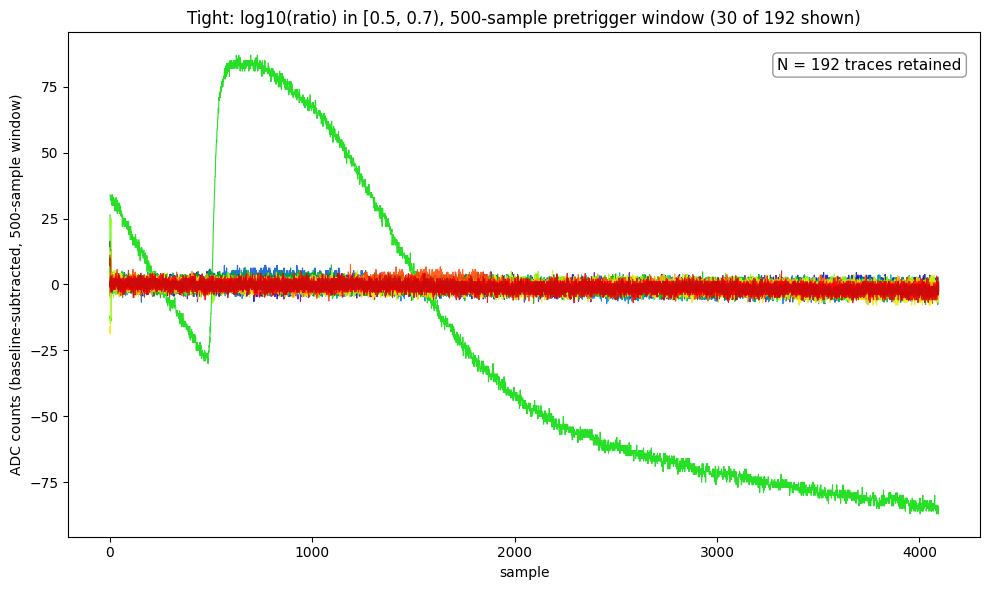

In [15]:
tight_mask = nonzero_dev_500 & (log_ratio_arr_500 >= 0.5) & (log_ratio_arr_500 < 0.7)
tight_indices = np.where(tight_mask)[0]

print(f"tight (0.5 to 0.7): {tight_mask.sum()} / {len(detector_id_arr)} traces retained")

N_SHOW_TIGHT = min(30, len(tight_indices))  # as many as stay visually distinguishable
rng_tight = np.random.default_rng(0)
tight_show = rng_tight.choice(tight_indices, size=N_SHOW_TIGHT, replace=False)
colors_tight = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, N_SHOW_TIGHT))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(tight_show, colors_tight):
    trace = pulses[i] - bmean_arr_500[i]
    ax.plot(trace, linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"Tight: log10(ratio) in [0.5, 0.7), 500-sample pretrigger window "
             f"({N_SHOW_TIGHT} of {tight_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {tight_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

### Tight, AI-filtered: same slice with `excursion_band_AI`

Same `[0.5, 0.7)` window as above, but using the library's `excursion_band_AI` cut, which additionally removes any trace `pulse_cuts.looks_like_pulse` judges to contain a real, sustained pulse (a long *consecutive* run of samples near the trace's own peak) rather than an ordinary noise fluctuation -- see `python/README.md` for how that heuristic and its `min_duration=50` threshold were picked from this same dataset. Both `looks_like_pulse` and `excursion_band_AI` are tagged `under_development`: this is a judgment-call heuristic, not a validated physical criterion, so treat it as a candidate refinement to check rather than ground truth.

tight, AI-filtered (0.5 to 0.7, pulse-like traces removed): 179 / 1517 traces retained


/var/folders/qs/y0dxxqrn4rd_pc96p6hnq51w0000gn/T/ipykernel_5973/1398657576.py:1: UserWarning: excursion_band_AI is marked under_development: excursion_band ([0.5, 0.7) by default) with looks_like_pulse traces removed -- i.e. 'whatever Claude judged to be a real pulse, taken out.' Both the band and the pulse-shape veto are judgment calls; treat this as an exploratory variant of excursion_band, not an independently validated cut, and check what it removes before trusting it on a new dataset.
  ai_mask = pc.excursion_band_AI(pulses, config_500)
/Users/villaa/Research/NSDF-Data/python/pulse_cuts.py:151: UserWarning: looks_like_pulse is marked under_development: 'looks like a pulse' is a judgment call, not a validated physical criterion. Flags traces whose excursion stays near its own peak for a long *consecutive* run (excursion_duration >= min_duration), which a real detector pulse's rise-then-decay does and ordinary noise usually doesn't. default min_duration=50 was picked by eye from a r

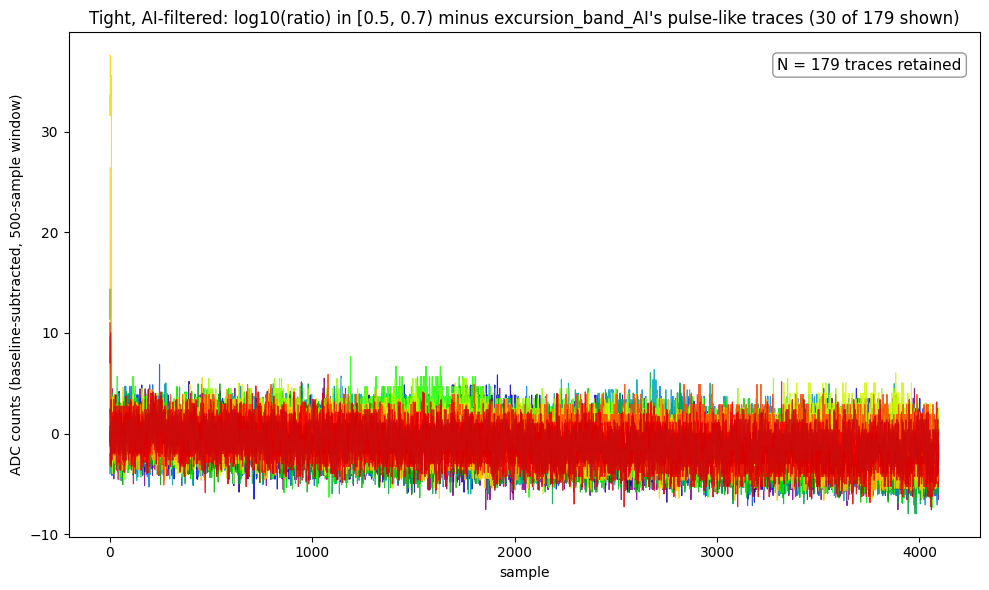

In [16]:
ai_mask = pc.excursion_band_AI(pulses, config_500)
ai_indices = np.where(ai_mask)[0]

print(f"tight, AI-filtered (0.5 to 0.7, pulse-like traces removed): {ai_mask.sum()} / {len(detector_id_arr)} traces retained")

N_SHOW_AI = min(30, len(ai_indices))  # as many as stay visually distinguishable
rng_ai = np.random.default_rng(0)
ai_show = rng_ai.choice(ai_indices, size=N_SHOW_AI, replace=False)
colors_ai = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, N_SHOW_AI))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(ai_show, colors_ai):
    trace = pulses[i] - bmean_arr_500[i]
    ax.plot(trace, linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"Tight, AI-filtered: log10(ratio) in [0.5, 0.7) minus "
             f"excursion_band_AI's pulse-like traces ({N_SHOW_AI} of {ai_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {ai_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

### What the AI filter removes: rejected by `excursion_band_AI`, kept by `excursion_band`

The Tight cut (`excursion_band`, `[0.5, 0.7)`) keeps 192 traces; `excursion_band_AI` keeps 179 of those same 192, having flagged the other 13 as `looks_like_pulse`. Same trace-overlay format as every other example section, showing all 13 rejected traces (not a random subsample, since there are few enough to show in full).

rejected by excursion_band_AI, kept by excursion_band (tight): 13 / 1517 traces


/var/folders/qs/y0dxxqrn4rd_pc96p6hnq51w0000gn/T/ipykernel_5973/3166531584.py:1: UserWarning: excursion_band_AI is marked under_development: excursion_band ([0.5, 0.7) by default) with looks_like_pulse traces removed -- i.e. 'whatever Claude judged to be a real pulse, taken out.' Both the band and the pulse-shape veto are judgment calls; treat this as an exploratory variant of excursion_band, not an independently validated cut, and check what it removes before trusting it on a new dataset.
  rejected_by_ai_mask = pc.excursion_band(pulses, config_500) & ~pc.excursion_band_AI(pulses, config_500)


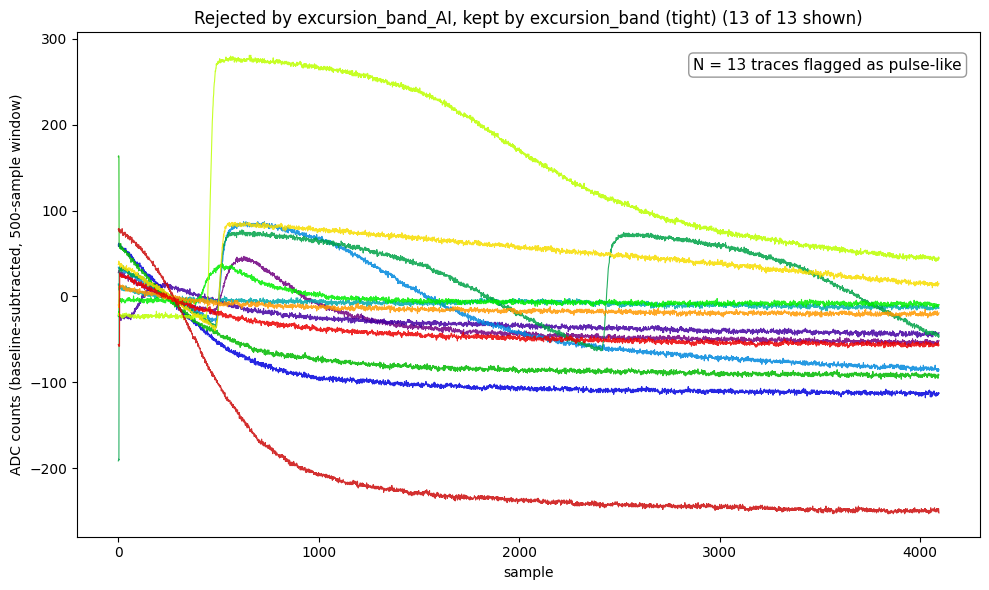

In [17]:
rejected_by_ai_mask = pc.excursion_band(pulses, config_500) & ~pc.excursion_band_AI(pulses, config_500)
rejected_by_ai_indices = np.where(rejected_by_ai_mask)[0]

print(f"rejected by excursion_band_AI, kept by excursion_band (tight): "
      f"{rejected_by_ai_mask.sum()} / {len(detector_id_arr)} traces")

N_SHOW_REJECTED = min(30, len(rejected_by_ai_indices))
rng_rejected = np.random.default_rng(0)
rejected_show = rng_rejected.choice(rejected_by_ai_indices, size=N_SHOW_REJECTED, replace=False)
colors_rejected = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, N_SHOW_REJECTED))

fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(rejected_show, colors_rejected):
    trace = pulses[i] - bmean_arr_500[i]
    ax.plot(trace, linewidth=0.8, color=color, alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"Rejected by excursion_band_AI, kept by excursion_band (tight) "
             f"({N_SHOW_REJECTED} of {rejected_by_ai_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {rejected_by_ai_mask.sum()} traces flagged as pulse-like", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

### Tight plus a `bstd` cap (Branch 2)

Branch 2's cuts so far look only at `ratio`. The first cut of this notebook also capped `bstd` (`bstd < 32.48`, the 75th percentile of the 1000-sample `bstd`). Here the same number is applied as a cap on Branch 2's own 500-sample `bstd` (`bstd_arr_500`), on top of the Tight cut. The same value is much looser in the 500-sample window than it was for the 1000-sample one (see the printed percentile), so this is a starting point for choosing the cap, not a finished cut. The plot shows the same 30 traces as the Tight plot above, minus any the cap removes, so the two compare directly.

Tight + bstd(500) < 32.48: 189 / 1517 traces retained (Tight alone: 192, removed 3)
same cap on Loose: 744 -> 738
32.48 is the 97.9th percentile of the 500-sample bstd (its median is 1.54); for the 1000-sample bstd it is the 75th
large trace in the Tight sample: event 11539, max |deviation| 87, bstd(500) = 18.05, kept by the cap: True


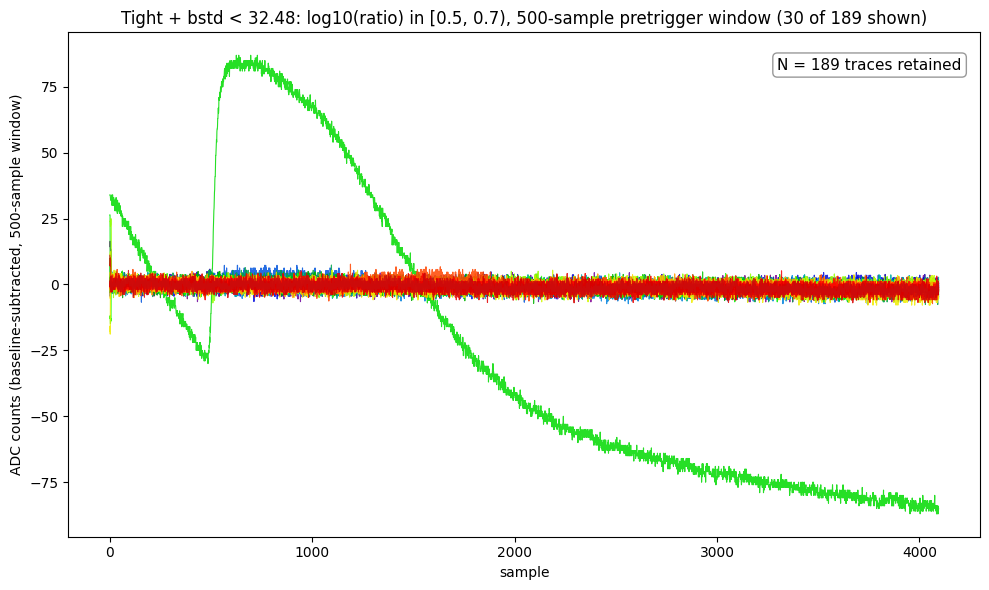

In [18]:
BSTD_CAP = 32.48   # same number as the first cut's bstd cap (the p75 of the 1000-sample bstd)

capped_mask = tight_mask & (bstd_arr_500 < BSTD_CAP)
capped_indices = np.where(capped_mask)[0]

print(f"Tight + bstd(500) < {BSTD_CAP}: {capped_mask.sum()} / {len(detector_id_arr)} traces retained "
      f"(Tight alone: {tight_mask.sum()}, removed {(tight_mask & ~capped_mask).sum()})")
print(f"same cap on Loose: {loose_mask.sum()} -> {(loose_mask & (bstd_arr_500 < BSTD_CAP)).sum()}")
print(f"{BSTD_CAP} is the {100 * np.mean(bstd_arr_500 < BSTD_CAP):.1f}th percentile of the 500-sample bstd "
      f"(its median is {np.median(bstd_arr_500):.2f}); for the 1000-sample bstd it is the 75th")

# the large trace in the Tight sample above (the obvious green one): the largest-amplitude trace shown there
amplitude = np.array([np.max(np.abs(pulses[i] - bmean_arr_500[i])) for i in tight_show])
green = tight_show[int(np.argmax(amplitude))]
print(f"large trace in the Tight sample: event {detector_id_arr[green].split('_')[0]}, "
      f"max |deviation| {amplitude.max():.0f}, bstd(500) = {bstd_arr_500[green]:.2f}, "
      f"kept by the cap: {bool(capped_mask[green])}")

shown = [k for k, i in enumerate(tight_show) if capped_mask[i]]   # keep each trace's color from the Tight plot
fig, ax = plt.subplots(figsize=(10, 6))
for k in shown:
    i = tight_show[k]
    ax.plot(pulses[i] - bmean_arr_500[i], linewidth=0.8, color=colors_tight[k], alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"Tight + bstd < {BSTD_CAP}: log10(ratio) in [0.5, 0.7), 500-sample pretrigger window "
             f"({len(shown)} of {capped_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {capped_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

What the cap removes: the traces in the Tight cut whose 500-sample `bstd` is at or above the cap. Colors are assigned within each plot, so the green line here is not the green trace of the plot above.

removed by the cap: 3 of the 192 Tight traces


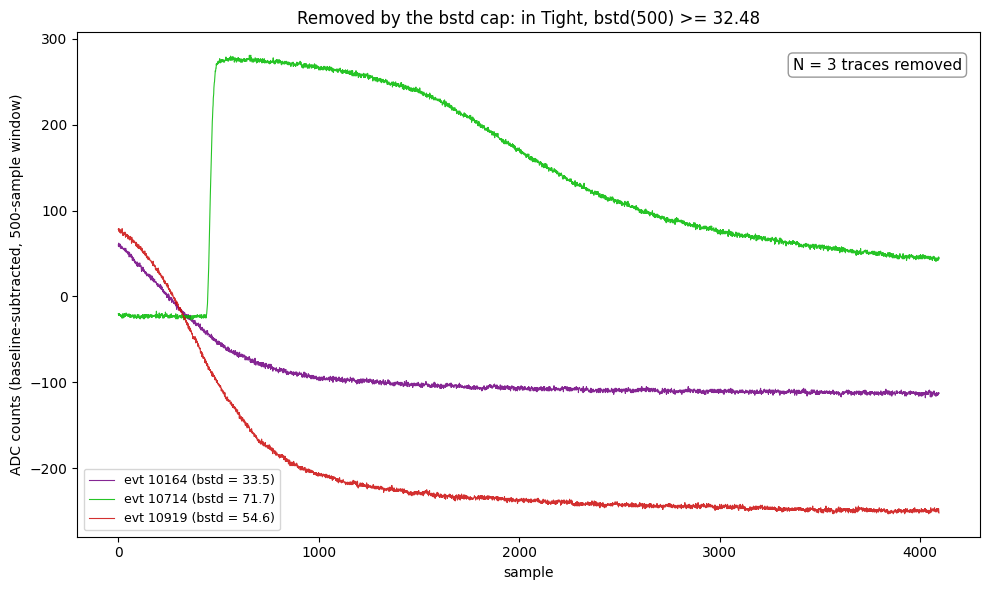

In [19]:
removed_by_cap = np.where(tight_mask & ~capped_mask)[0]
print(f"removed by the cap: {len(removed_by_cap)} of the {tight_mask.sum()} Tight traces")

colors_removed = plt.cm.nipy_spectral(np.linspace(0.05, 0.95, len(removed_by_cap)))
fig, ax = plt.subplots(figsize=(10, 6))
for i, color in zip(removed_by_cap, colors_removed):
    ax.plot(pulses[i] - bmean_arr_500[i], linewidth=0.8, color=color, alpha=0.85,
            label=f"evt {detector_id_arr[i].split('_')[0]} (bstd = {bstd_arr_500[i]:.1f})")

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"Removed by the bstd cap: in Tight, bstd(500) >= {BSTD_CAP}")
ax.legend(fontsize=9, loc="lower left")
ax.text(0.98, 0.95, f"N = {len(removed_by_cap)} traces removed", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

How the choice of cap matters, and how it compares with the `excursion_band_AI` veto above: for each cap, how many of the 192 Tight traces it removes, and how many of those are among the 13 the AI veto rejects.

In [20]:
print(f"{'bstd(500) cap':>14} {'Tight kept':>11} {'removed':>8} {'AI-rejected removed':>20} {'AI-kept removed':>16}")
for cap in (32.48, 20, 10, 5, 3, 2.5):
    kept = tight_mask & (bstd_arr_500 < cap)
    removed = tight_mask & ~kept
    print(f"{cap:14g} {kept.sum():11d} {removed.sum():8d} "
          f"{(removed & rejected_by_ai_mask).sum():20d} {(removed & ai_mask).sum():16d}")
print(f"\nbstd(500) of the {rejected_by_ai_mask.sum()} traces the AI veto rejects: "
      f"{bstd_arr_500[rejected_by_ai_mask].min():.2f} to {bstd_arr_500[rejected_by_ai_mask].max():.2f}")
print(f"bstd(500) of the {ai_mask.sum()} traces it keeps: up to {bstd_arr_500[ai_mask].max():.2f}")

 bstd(500) cap  Tight kept  removed  AI-rejected removed  AI-kept removed
         32.48         189        3                    3                0
            20         186        6                    6                0
            10         181       11                   11                0
             5         180       12                   12                0
             3         179       13                   13                0
           2.5         178       14                   13                1

bstd(500) of the 13 traces the AI veto rejects: 4.65 to 71.75
bstd(500) of the 179 traces it keeps: up to 2.83


**Does the cap remove the obvious green trace? No.** At `bstd < 32.48` the cap removes only 3 of the 192 Tight traces (and 6 of the 744 Loose ones). The large green trace in the Tight plot (a decaying baseline that runs from about +33 to -30 over the pretrigger window, then a pulse rising near sample 500) has a 500-sample `bstd` of 18.05, well under the cap, so it is kept. The three traces the cap does remove have `bstd` of 33 to 72 and are all among the 13 the AI veto rejects.

The scan shows why 32.48 is too loose here: it is the 98th percentile of the 500-sample `bstd`, not the 75th. A cap below 18 is needed to remove the green trace. At 10, 5 and 3 the cap removes 11, 12 and 13 Tight traces, every one of them among the 13 that `excursion_band_AI` rejects; at 3 it removes exactly those 13, with a gap between the largest `bstd` among the AI-kept traces (2.83) and the smallest among the AI-rejected ones (4.65). At 2.5 it starts removing traces the AI veto keeps. So for this dataset a `bstd` cap of about 3 to 4 separates the same 13 traces as the pulse-shape veto, by a much simpler criterion.

### Histogram of `bstd` for the 500-sample pretrigger window (Branch 2)

We use the plot below to see whether adjusting the `bstd` cut is worth it: a `bstd` threshold can only help if the traces we want to remove sit apart from the ones we want to keep. It shows all Detector 0 / Channel 0 traces (1517) as a histogram of `log10(bstd)` on the 500-sample window, with the Tight selection overlaid in orange, the 1000-sample `bstd` as a black outline for comparison, and the 32.48 cap as a dashed line. The count axis is logarithmic because the quiet population dominates and the interesting part is the tail.

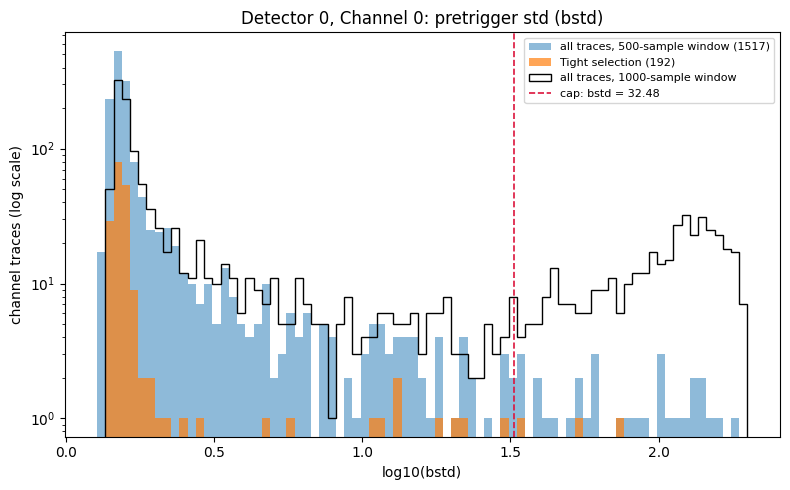

bstd percentiles      p50    p75    p90    p95    p98    max
 500-sample window    1.54   1.69   3.42  10.53  33.39  179.0
1000-sample window    1.88  32.48 124.91 149.76 170.51  199.4

500-sample bstd range   all traces   in Tight
               0 to 2         1249        175
               2 to 5          158          5
           5 to 32.48           78          9
             >= 32.48           32          3


In [21]:
log_bstd_500 = np.log10(bstd_arr_500)
log_bstd_1000 = np.log10(bstd_arr)
bins = np.linspace(min(log_bstd_500.min(), log_bstd_1000.min()), max(log_bstd_500.max(), log_bstd_1000.max()), 80)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(log_bstd_500, bins=bins, alpha=0.5, label=f"all traces, 500-sample window ({len(bstd_arr_500)})")
ax.hist(log_bstd_500[tight_mask], bins=bins, alpha=0.7, label=f"Tight selection ({tight_mask.sum()})")
ax.hist(log_bstd_1000, bins=bins, histtype="step", color="k", linewidth=1.0, label="all traces, 1000-sample window")
ax.axvline(np.log10(BSTD_CAP), color="crimson", linestyle="--", linewidth=1.2, label=f"cap: bstd = {BSTD_CAP}")
ax.set_yscale("log")
ax.set_xlabel("log10(bstd)")
ax.set_ylabel("channel traces (log scale)")
ax.set_title("Detector 0, Channel 0: pretrigger std (bstd)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print("bstd percentiles      p50    p75    p90    p95    p98    max")
for label, arr in (("500-sample window", bstd_arr_500), ("1000-sample window", bstd_arr)):
    q = np.percentile(arr, [50, 75, 90, 95, 98])
    print(f"{label:>18} {q[0]:7.2f}{q[1]:7.2f}{q[2]:7.2f}{q[3]:7.2f}{q[4]:7.2f}{arr.max():7.1f}")

edges = [0, 2, 5, BSTD_CAP, np.inf]
print("\n500-sample bstd range   all traces   in Tight")
for lo, hi in zip(edges[:-1], edges[1:]):
    sel = (bstd_arr_500 >= lo) & (bstd_arr_500 < hi)
    label = f"{lo:g} to {hi:g}" if np.isfinite(hi) else f">= {lo:g}"
    print(f"{label:>21} {sel.sum():12d} {(sel & tight_mask).sum():10d}")

**Reading the histogram.** The 500-sample `bstd` is sharply peaked near 1.5 (median 1.54; 1249 of the 1517 traces are below 2) with a sparse tail out to 179. The 1000-sample `bstd` (black outline) has a second population at `bstd` of roughly 80 to 180 (`log10` about 1.9 to 2.25): the pulse-contaminated baselines discussed above, pulses that start between samples 500 and 1000. That population is why its 75th percentile is 32.48 and its 90th is 125. It is largely gone in the 500-sample window (32 traces, 2%, at or above 32.48), so the same number that sat in the valley between the two populations for the 1000-sample window now sits in a sparse tail.

Of the 192 Tight traces, 175 are in the main peak (`bstd` below 2), 5 are between 2 and 5, 9 between 5 and 32.48, and 3 are above the cap. The 17 with `bstd` of 2 or more are the 13 the AI veto rejects (`bstd` 4.65 and up) and 4 it keeps (2.0 to 2.83). There is no gap in the overall distribution between about 2 and 30: the tail falls smoothly (158 traces between 2 and 5, 78 between 5 and 32.48, across all traces). So the gap between 2.83 and 4.65 found above is a property of the Tight selection, not a natural break in the `bstd` distribution, and a cap of about 3 to 4 needs some other justification than the shape of this histogram.

### A separate `bstd` cut: `log10(bstd) < 0.5`

We add a separate cut on the baseline scatter alone, independent of `ratio`: `log10(bstd) < 0.5` on the 500-sample window. The quantity being cut on, `log10(bstd)`, is the horizontal axis of the histogram above; in terms of `bstd` itself, it selects traces with `bstd` below 3.16 (10^0.5). The cell below applies it on its own and after the Tight cut. The plot shows the same 30 traces as the Tight plot above, minus any this cut removes, so the two compare directly.

log10(bstd) < 0.5 (bstd < 3.16) alone: 1355 / 1517 traces
Tight alone: 192; Tight + log10(bstd) < 0.5: 179 (removed 13)
Loose alone: 744; Loose + log10(bstd) < 0.5: 691
removed set is identical to the traces excursion_band_AI rejects: True; retained set identical to excursion_band_AI's: True
the large green trace of the Tight plot (event 11539, bstd(500) = 18.05): kept by this cut: False


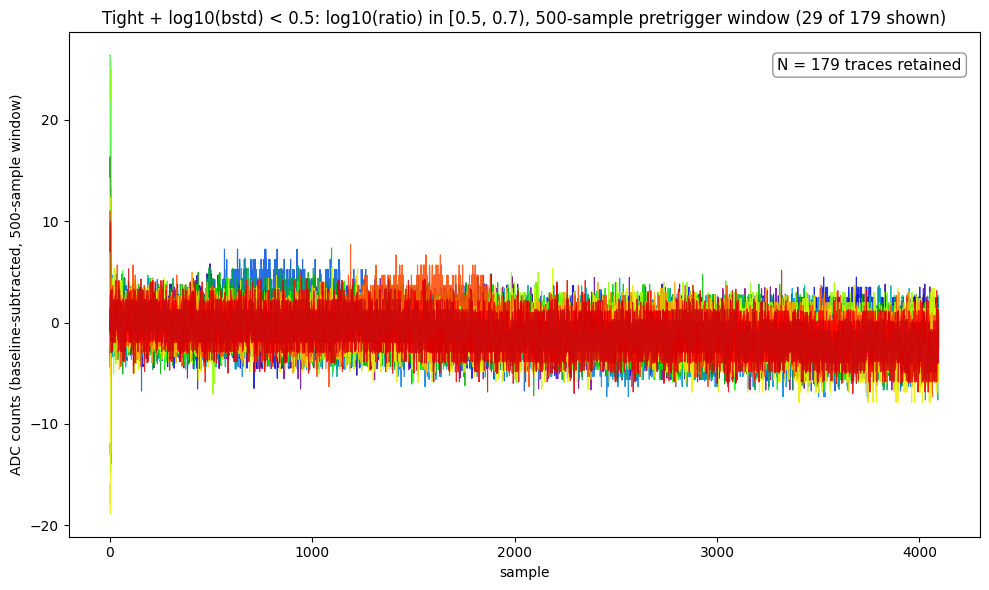

In [22]:
LOG_BSTD_MAX = 0.5   # log10(bstd) < 0.5, i.e. bstd < 3.16

quiet_bstd_mask = log_bstd_500 < LOG_BSTD_MAX          # the separate cut, on bstd alone
tight_quiet_mask = tight_mask & quiet_bstd_mask        # both cuts

print(f"log10(bstd) < {LOG_BSTD_MAX} (bstd < {10 ** LOG_BSTD_MAX:.2f}) alone: "
      f"{quiet_bstd_mask.sum()} / {len(detector_id_arr)} traces")
print(f"Tight alone: {tight_mask.sum()}; Tight + log10(bstd) < {LOG_BSTD_MAX}: {tight_quiet_mask.sum()} "
      f"(removed {(tight_mask & ~quiet_bstd_mask).sum()})")
print(f"Loose alone: {loose_mask.sum()}; Loose + log10(bstd) < {LOG_BSTD_MAX}: {(loose_mask & quiet_bstd_mask).sum()}")
print(f"removed set is identical to the traces excursion_band_AI rejects: "
      f"{np.array_equal(tight_mask & ~quiet_bstd_mask, rejected_by_ai_mask)}; "
      f"retained set identical to excursion_band_AI's: {np.array_equal(tight_quiet_mask, ai_mask)}")
print(f"the large green trace of the Tight plot (event {detector_id_arr[green].split('_')[0]}, "
      f"bstd(500) = {bstd_arr_500[green]:.2f}): kept by this cut: {bool(tight_quiet_mask[green])}")

shown = [k for k, i in enumerate(tight_show) if tight_quiet_mask[i]]   # keep each trace's color from the Tight plot
fig, ax = plt.subplots(figsize=(10, 6))
for k in shown:
    i = tight_show[k]
    ax.plot(pulses[i] - bmean_arr_500[i], linewidth=0.8, color=colors_tight[k], alpha=0.85)

ax.set_xlabel("sample")
ax.set_ylabel("ADC counts (baseline-subtracted, 500-sample window)")
ax.set_title(f"Tight + log10(bstd) < {LOG_BSTD_MAX}: log10(ratio) in [0.5, 0.7), 500-sample pretrigger window "
             f"({len(shown)} of {tight_quiet_mask.sum()} shown)")
ax.text(0.98, 0.95, f"N = {tight_quiet_mask.sum()} traces retained", transform=ax.transAxes,
        ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6"))
fig.tight_layout()
plt.show()

**Result.** On its own the cut keeps 1355 of the 1517 traces (89%). When applied after the Tight cut, it keeps **179** and removes 13. The large green trace of the Tight plot is removed (its `bstd` is 18.05), and the sample above is flat noise with no pulses or drifts left; a few traces show brief stretches of somewhat larger scatter, up to about 7 counts. The 13 removed traces are exactly the ones `excursion_band_AI` rejects, and the 179 retained are exactly its selection (checked above).

The exact match is a meaningful agreement between two different criteria, though not a full test of the `bstd` cut. The threshold 0.5 was chosen from the histogram alone, where the distribution starts to rise sharply, without reference to the `excursion_band_AI` selection, and it removes exactly the 13 traces that cut rejects on pulse shape. The match is also not sensitive to the exact value: the Tight traces the AI cut keeps have `bstd` up to 2.83 and the 13 it rejects start at 4.65 (see the cap scan above), so any threshold in that gap, 3.16 included, gives the same result. It is not a full test because the pulse-shape classification is itself a heuristic, and because this is one detector and channel: it shows that baseline scatter alone separates the two groups within the Tight cut, not that the cut would work on another selection.

Applied to the Loose cut, the same `bstd` cut removes 53 of the 744 traces (691 kept); how many of those 53 are pulse-like has not been checked.

### Archive the AI-filtered selection

Save this `excursion_band_AI` selection's `detector_id`s to `archives/good_noise.h5` (via `pulse_archive.py`) so later notebooks can read back exactly which traces were kept here instead of re-deriving it -- see `archives/README.md` for the archive's layout. This is the first entry for this series/detector/channel; re-running this cell after the cut changes will overwrite it, not append a second copy.

In [23]:
import pulse_archive as parchive

SERIES = "07221203_2025"
DUMP = "F0001"
archive_path = Path.cwd().parents[1] / "archives" / "good_noise.h5"

parchive.save_good_events(
    archive_path, series=SERIES, detector=DETECTOR, channel=CHANNEL,
    detector_ids=detector_id_arr[ai_indices],
    cut_name="excursion_band_AI", cut_status=pc.excursion_band_AI.status,
    cut_params={"low": 0.5, "high": 0.7, "min_duration": 50},
    n_total=len(detector_id_arr), dump=DUMP, config=config_500,
    source_notebook="07221203_2025_dump1_noise.ipynb",
)

print(f"archived {ai_mask.sum()} good events to {archive_path}")
print(parchive.list_archive(archive_path))

archived 179 good events to /Users/villaa/Research/NSDF-Data/archives/good_noise.h5
{'07221203_2025': {0: {0: 179}}}
